In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [10]:
x=6*np.random.rand(200,1)-3
y=0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200,1)
print(f"{y.shape},")

(200, 1),


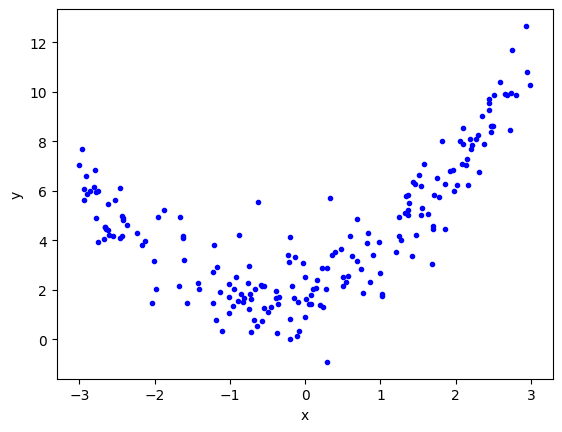

In [12]:
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [13]:
X_train,X_test,y_train,y_test=train_test_split(x,y,random_state=42)

In [14]:
lr=LinearRegression()

In [15]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)

0.12774729798535722

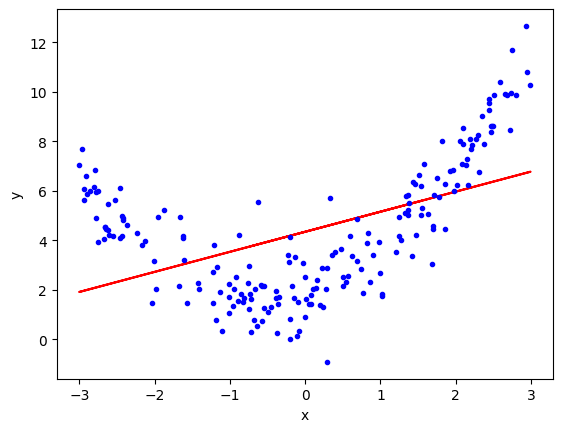

In [17]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(x,y,'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [18]:
poly=PolynomialFeatures(degree=2,include_bias=True)

In [19]:
X_train_trans=poly.fit_transform(X_train)
X_test_trans=poly.transform(X_test)
X_test_trans[1:4]

array([[ 1.        ,  1.41709004,  2.00814417],
       [ 1.        , -0.11109315,  0.01234169],
       [ 1.        , -2.85480575,  8.14991586]])

In [20]:
lr=LinearRegression()
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_predict_trans=lr.predict(X_test_trans)

In [22]:
r2_score(y_test,y_predict_trans)

0.7850040741695432

In [33]:
x_new=np.linspace(-3,3,500).reshape(500,1)
n_new_poly=poly.transform(x_new)
y_new=lr.predict(n_new_poly)

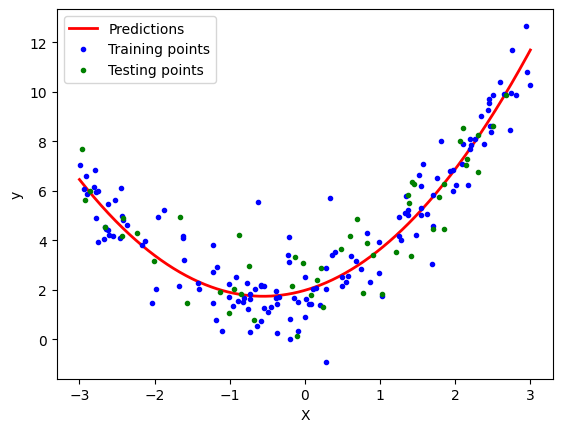

In [34]:
plt.plot(x_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()